# Coursework: Interpretable Machine Learning with Decision Tree, Random Forest, and Feed-Forward Neural Network

## Group Members

| # | Full Name | Student Number | Email | Student ID |
|---|-----------|---------------------|-------|---|
| 1 | Kigozi Allan | 2400725792 | chigozieallanie@gmail.com | 24/U/25792/PS |
| 2 | Keith Paul Kato | 2400726593 | keithpaulkato@gmail.com | 24/U/26593/EVE |
| 3 | Mugole Joel | 2400707060 | joelmugole74@gmail.com | 24/U/07060/EVE |
| 4 | Nalubega Shadiah | 2400708715 | shadiaahmed1302@gmail.com | 24/U/08715/EVE |
| 5 | Ageno Elizabeth | 2400725850 | eageno555@gmail.com | 24/U/25850/PS |

## 1. Introduction and Problem Statement

For this coursework we picked a weather dataset that records solar radiation together with the conditions around each measurement. The goal is to predict the radiation value (in W/m²) from the other variables, and then use SHAP and LIME to actually understand why each model makes the prediction it does.

We chose this dataset because solar radiation is something we can reason about physically. We already expect time of day, season and temperature to matter, so when we look at the explanations later we have a way to check whether the models are picking up on something sensible or just memorising noise.

The three models we train are:

1. A Decision Tree Regressor, which is the simplest and easiest to read.
2. A Random Forest Regressor, which is usually stronger but a bit harder to interpret directly.
3. A Feed-Forward Neural Network (sklearn's MLPRegressor), which we expect to perform well but be the least transparent of the three.

After training, we run SHAP for a global view of feature importance and LIME for a local explanation of one specific prediction, then compare what the two methods say about each model.

The full pipeline below follows the workflow we covered in class: load the data, explore it, do the feature engineering, split into train and validation, train the models with a small cross-validated tuning step, evaluate them with RMSE / MAE / R², and finally interpret the results.

## 2. Imports and Settings

In [37]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import shap
from lime.lime_tabular import LimeTabularExplainer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

## 3. Load the Dataset

The dataset (`Train.csv`) contains 15-minute weather readings from several stations, plus station metadata like country, elevation, latitude, longitude and installation height. Our target column is `radiation (W/m2)`.

The full file is large, so to keep training and (especially) the SHAP / LIME computations practical on a normal laptop we work with a stratified sample of the rows. The sampling is done per station so that we keep roughly the same mix of stations as the original data.

In [38]:
DATA_DIR = Path(".")
raw_df = pd.read_csv(DATA_DIR / "Train.csv")

target_col = "radiation (W/m2)"
assert target_col in raw_df.columns, f"Expected target column '{target_col}' was not found."

print("Full dataset shape:", raw_df.shape)

# Stratified sample by station so all stations remain represented
SAMPLE_SIZE = 30000
if len(raw_df) > SAMPLE_SIZE:
    frac = SAMPLE_SIZE / len(raw_df)
    df = (
        raw_df.groupby("station", group_keys=False)
              .apply(lambda g: g.sample(frac=frac, random_state=RANDOM_STATE))
              .reset_index(drop=True)
    )
else:
    df = raw_df.copy()

print("Working sample shape:", df.shape)
df.head()

Full dataset shape: (642175, 13)
Working sample shape: (29999, 12)


,ID,timestamp,precipitation (mm),radiation (W/m2),relativehumidity (-),temperature (degrees Celsius),station_name,country,installation_height,elevation,latitude,longitude
0,b90ca874_2016-03_SDTZXO,2016-03-27 04:45:00,0.0,225.0,0.71,15.2,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936
1,b90ca874_2016-01_6RW3AG,2016-01-14 20:15:00,0.0,0.0,0.98,13.1,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936
2,b90ca874_2016-05_I7163I,2016-05-14 23:45:00,0.0,0.0,1.00,10.2,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936
3,b90ca874_2016-01_EMO53D,2016-01-11 22:15:00,0.0,0.0,0.96,13.1,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936
4,b90ca874_2016-09_WVMECT,2016-09-10 03:15:00,0.0,0.0,0.88,9.5,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ID                             29999 non-null  str    
 1   timestamp                      29999 non-null  str    
 2   precipitation (mm)             29999 non-null  float64
 3   radiation (W/m2)               29999 non-null  float64
 4   relativehumidity (-)           29999 non-null  float64
 5   temperature (degrees Celsius)  29999 non-null  float64
 6   station_name                   29999 non-null  str    
 7   country                        29999 non-null  str    
 8   installation_height            29999 non-null  float64
 9   elevation                      29999 non-null  float64
 10  latitude                       29999 non-null  float64
 11  longitude                      29999 non-null  float64
dtypes: float64(8), str(4)
memory usage: 2.7 MB


## 4. Exploratory Data Analysis

Before building any models we wanted to get a feel for the data. In this section we check how many missing values each column has, look at how the radiation target is distributed, and check how the main weather variables relate to it. The goal here is mostly to spot anything obviously wrong (heavy missingness, weird outliers, suspicious correlations) before we commit to a feature set.

**Target skew and “nighttime zeros”.** Solar radiation is physically zero (or near-zero) throughout the night, so the distribution of `radiation (W/m²)` piles up at zero and low values rather than looking bell-shaped. That is not missing data: it reflects darkness. For regression it means a strong **value imbalance**: many easy rows where the correct answer is “no sun”, and fewer daytime rows where the model must track clouds and weather. Models that encode time of day well get much of their error reduction from separating day from night; metrics on the full validation set therefore mix “easy night” errors with harder daytime errors. The quick counts in the next cell quantify how large that zero/low mass is.

In [40]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("Missing-value percentages by column (%):")
print(missing_pct)

Missing-value percentages by column (%):
ID                               0.0
timestamp                        0.0
precipitation (mm)               0.0
radiation (W/m2)                 0.0
relativehumidity (-)             0.0
temperature (degrees Celsius)    0.0
station_name                     0.0
country                          0.0
installation_height              0.0
elevation                        0.0
latitude                         0.0
longitude                        0.0
dtype: float64


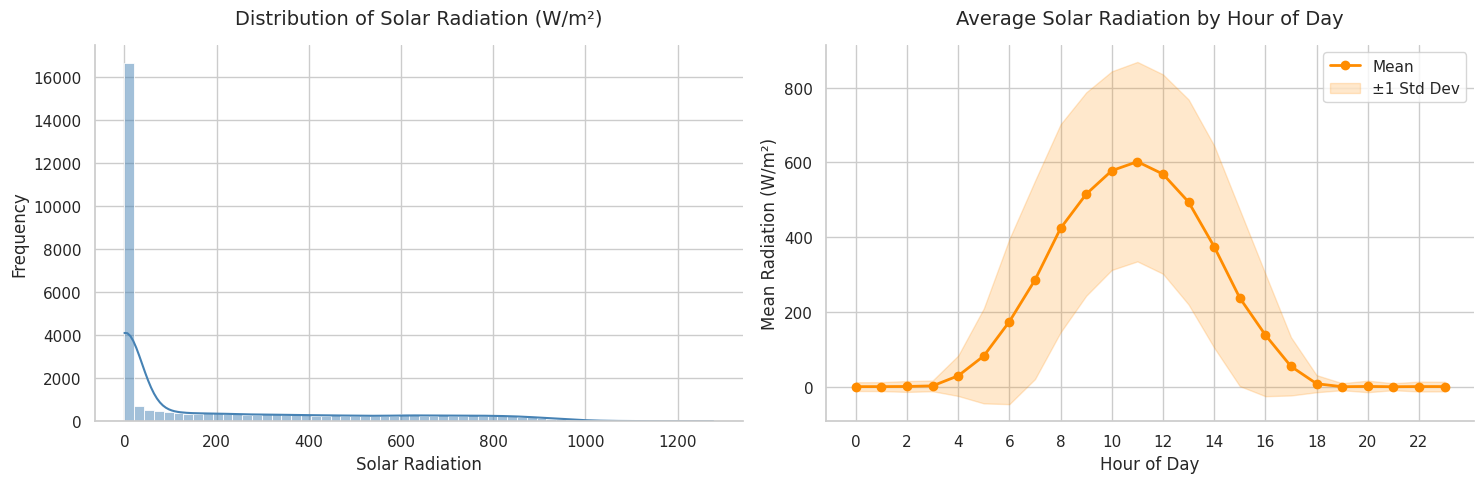

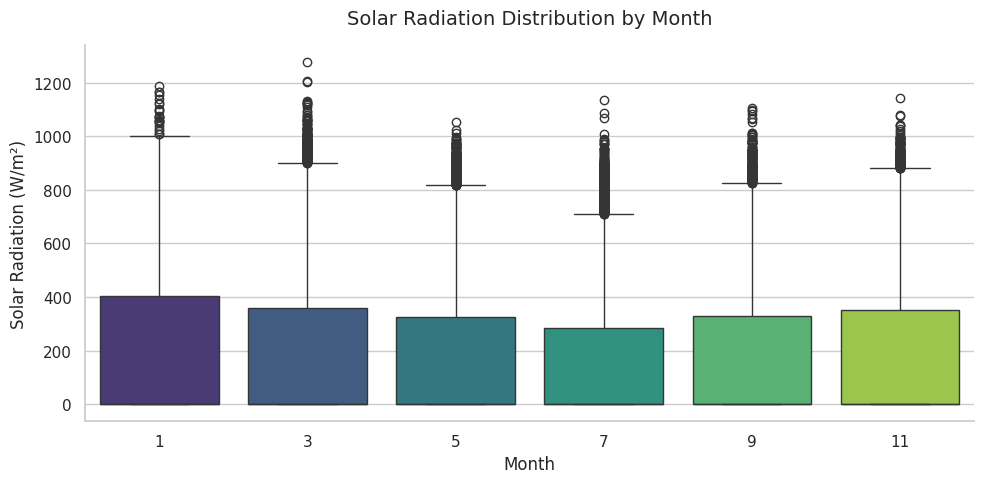

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set professional aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.figsize': (14, 6)
})

# 1. Target Distribution & Hourly Trend
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution with KDE
sns.histplot(df[target_col].dropna(), bins=60, kde=True, color="steelblue", ax=axes[0])
axes[0].set_title("Distribution of Solar Radiation (W/m²)", pad=15)
axes[0].set_xlabel("Solar Radiation")
axes[0].set_ylabel("Frequency")

# Hourly Trend
df["_ts"] = pd.to_datetime(df["timestamp"], errors="coerce")
df["_hour"] = df["_ts"].dt.hour
df["_month"] = df["_ts"].dt.month

hourly_stats = df.groupby("_hour")[target_col].agg(['mean', 'std']).reset_index()
axes[1].plot(hourly_stats['_hour'], hourly_stats['mean'], marker="o", color="darkorange", linewidth=2, label="Mean")
axes[1].fill_between(hourly_stats['_hour'], 
                     hourly_stats['mean'] - hourly_stats['std'],
                     hourly_stats['mean'] + hourly_stats['std'],
                     color="darkorange", alpha=0.2, label="±1 Std Dev")

axes[1].set_title("Average Solar Radiation by Hour of Day", pad=15)
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Mean Radiation (W/m²)")
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend()

sns.despine()
plt.tight_layout()
plt.show()

# 2. Monthly Trend (Boxplot)
plt.figure(figsize=(10, 5))
sns.boxplot(x="_month", y=target_col, data=df, palette="viridis")
plt.title("Solar Radiation Distribution by Month", pad=15)
plt.xlabel("Month")
plt.ylabel("Solar Radiation (W/m²)")
sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
# How skewed is the target? (Uses columns created in the plots above: _hour, target_col.)
rad = df[target_col].dropna()
zero_pct = float((rad == 0).mean() * 100)
low_pct = float((rad <= 1.0).mean() * 100)
_h = df["_hour"]
night_mask = ((_h >= 0) & (_h <= 6)) | ((_h >= 19) & (_h <= 23))
night_sub = df.loc[night_mask, target_col].dropna()
night_zero_pct = float((night_sub == 0).mean() * 100) if len(night_sub) else float("nan")

print(f"Rows with exactly zero radiation: {zero_pct:.1f}% of non-missing target values")
print(f"Rows with radiation <= 1 W/m²: {low_pct:.1f}%")
print(
    f"Among evening/night hours (0–6h and 19–23h), share with zero radiation: {night_zero_pct:.1f}%"
)
print(
    "\nImplication: metrics aggregate night (often near-zero) and day; interpret RMSE/MAE with this skew in mind."
)


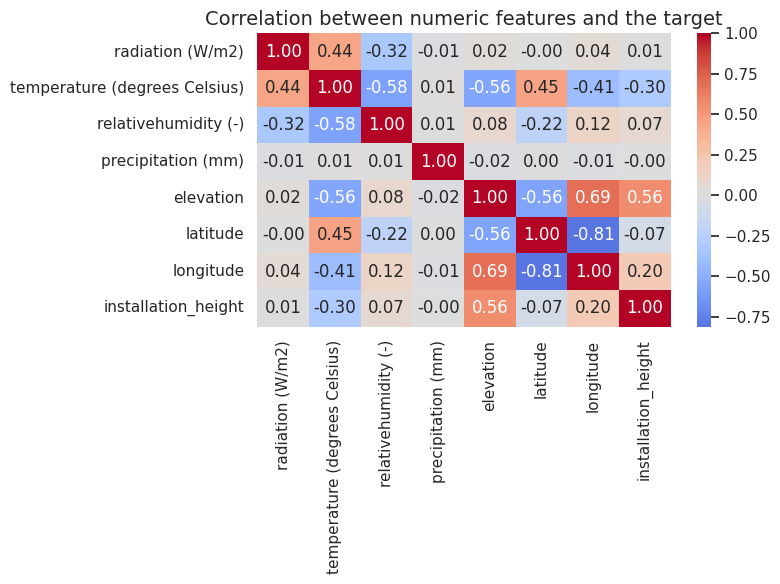

In [42]:
numeric_for_corr = [
    "radiation (W/m2)",
    "temperature (degrees Celsius)",
    "relativehumidity (-)",
    "precipitation (mm)",
    "elevation",
    "latitude",
    "longitude",
    "installation_height",
]
available = [c for c in numeric_for_corr if c in df.columns]
corr = df[available].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation between numeric features and the target")
plt.tight_layout()
plt.show()

## 5. Feature Engineering

Time matters a lot for solar radiation, so we put some work into the time features instead of just feeding the raw timestamp. We pull out the year, month, day of year, hour and so on, and we also add sine and cosine versions of the hour and the month.

The reason for the sine/cosine trick is that hours and months are cyclic. If we left `hour` as a plain number, the model would think hour 23 and hour 0 are very far apart, when really they are right next to each other. The sin/cos encoding makes that wrap-around natural for the model.

In [43]:
def add_time_features(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    ts = pd.to_datetime(frame["timestamp"], errors="coerce")
    frame["year"] = ts.dt.year
    frame["month"] = ts.dt.month
    frame["day"] = ts.dt.day
    frame["hour"] = ts.dt.hour
    frame["minute"] = ts.dt.minute
    frame["day_of_week"] = ts.dt.dayofweek
    frame["day_of_year"] = ts.dt.dayofyear
    frame["is_weekend"] = (frame["day_of_week"] >= 5).astype(int)

    frame["hour_sin"] = np.sin(2 * np.pi * frame["hour"] / 24)
    frame["hour_cos"] = np.cos(2 * np.pi * frame["hour"] / 24)
    frame["month_sin"] = np.sin(2 * np.pi * frame["month"] / 12)
    frame["month_cos"] = np.cos(2 * np.pi * frame["month"] / 12)
    frame["doy_sin"] = np.sin(2 * np.pi * frame["day_of_year"] / 365.25)
    frame["doy_cos"] = np.cos(2 * np.pi * frame["day_of_year"] / 365.25)
    return frame

model_df = add_time_features(df)
model_df = model_df.drop(columns=["_ts", "_hour"], errors="ignore")
model_df = model_df.dropna(subset=[target_col]).reset_index(drop=True)

print("Prepared dataset shape:", model_df.shape)
model_df.head()

Prepared dataset shape: (29999, 27)


,ID,timestamp,precipitation (mm),radiation (W/m2),relativehumidity (-),temperature (degrees Celsius),station_name,country,installation_height,elevation,latitude,longitude,_month,year,month,day,hour,minute,day_of_week,day_of_year,is_weekend,hour_sin,hour_cos,month_sin,month_cos,doy_sin,doy_cos
0,b90ca874_2016-03_SDTZXO,2016-03-27 04:45:00,0.0,225.0,0.71,15.2,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,3,2016,3,27,4,45,6,87,1,0.866025,0.500000,1.0,6.123234e-17,0.997250,0.074117
1,b90ca874_2016-01_6RW3AG,2016-01-14 20:15:00,0.0,0.0,0.98,13.1,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,1,2016,1,14,20,15,3,14,0,-0.866025,0.500000,0.5,8.660254e-01,0.238513,0.971139
2,b90ca874_2016-05_I7163I,2016-05-14 23:45:00,0.0,0.0,1.00,10.2,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,5,2016,5,14,23,45,5,135,1,-0.258819,0.965926,0.5,-8.660254e-01,0.730644,-0.682758
3,b90ca874_2016-01_EMO53D,2016-01-11 22:15:00,0.0,0.0,0.96,13.1,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,1,2016,1,11,22,15,0,11,0,-0.500000,0.866025,0.5,8.660254e-01,0.188099,0.982150
4,b90ca874_2016-09_WVMECT,2016-09-10 03:15:00,0.0,0.0,0.88,9.5,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,9,2016,9,10,3,15,5,254,1,0.707107,0.707107,-1.0,-1.836970e-16,-0.941759,-0.336289


## 6. Define Features and Train / Validation Split

Now we separate the features from the target. We drop the row ID and the raw timestamp (we already turned the timestamp into the time features above) and keep everything else. The categorical columns (station, station name, country) are handled later inside each model's pipeline with one-hot encoding, so we don't touch them here.

We then split the data into a training set and a validation set, and use the same split for all three models so the comparison is fair.

In [44]:
drop_cols = [target_col, "ID", "timestamp"]
X = model_df.drop(columns=[c for c in drop_cols if c in model_df.columns])
y = model_df[target_col].astype(float)

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Total features:", X.shape[1])
print("Numeric features    :", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Numeric example     :", numeric_features[:8])
print("Categorical example :", categorical_features)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "| Validation:", X_valid.shape)

Total features: 24
Numeric features    : 22
Categorical features: 2
Numeric example     : ['precipitation (mm)', 'relativehumidity (-)', 'temperature (degrees Celsius)', 'installation_height', 'elevation', 'latitude', 'longitude', '_month']
Categorical example : ['station_name', 'country']
Train: (23999, 24) | Validation: (6000, 24)


## 7. Build the Three Models

We wrap each model in a scikit-learn `Pipeline` so that the preprocessing and the estimator are fitted together. This matters because it stops information from the validation set leaking into the training set through the imputer or the scaler.

The two tree-based models (Decision Tree and Random Forest) only need median imputation for numeric columns and one-hot encoding for the categorical ones. Trees do not care about the scale of the features, so we don't bother scaling them.

The neural network is a different story. Gradient-based training works much better when all the inputs are on a similar scale, so for the MLP we add a `StandardScaler` step on top of the same imputation and one-hot encoding.

In [45]:
def make_dense_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", make_dense_ohe()),
            ]),
            categorical_features,
        ),
    ]
)

mlp_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", make_dense_ohe()),
            ]),
            categorical_features,
        ),
    ]
)

models = {
    "Decision Tree": Pipeline(steps=[
        ("preprocessor", tree_preprocessor),
        ("model", DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=None,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
    "Feed-Forward Neural Network": Pipeline(steps=[
        ("preprocessor", mlp_preprocessor),
        ("model", MLPRegressor(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            learning_rate_init=0.001,
            max_iter=300,
            early_stopping=True,
            random_state=RANDOM_STATE,
        )),
    ]),
}

print("Models ready:", list(models.keys()))

Models ready: ['Decision Tree', 'Random Forest', 'Feed-Forward Neural Network']


## Hyperparameter Tuning and Cross-Validation

Picking hyperparameters by hand felt a bit arbitrary, so we added a small tuning step here using 3-fold cross-validation. We deliberately kept the search space small (a few values of `max_depth` for the trees and a couple of architectures for the network) because a full grid search on the whole training set would have taken too long for the notebook to stay practical.

Even so, this gives us a more honest sense of which settings the models actually prefer, instead of just trusting our first guess.

In [46]:
from sklearn.model_selection import GridSearchCV, KFold

tuning_sample_size = min(8000, len(X_train))
X_tune = X_train.sample(n=tuning_sample_size, random_state=RANDOM_STATE)
y_tune = y_train.loc[X_tune.index]

cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

tuning_specs = {
    "Decision Tree": {
        "pipeline": Pipeline(steps=[
            ("preprocessor", tree_preprocessor),
            ("model", DecisionTreeRegressor(random_state=RANDOM_STATE)),
        ]),
        "param_grid": {
            "model__max_depth": [8, 12],
            "model__min_samples_leaf": [1, 2],
            "model__min_samples_split": [2, 10],
        },
    },
    "Random Forest": {
        "pipeline": Pipeline(steps=[
            ("preprocessor", tree_preprocessor),
            ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
        ]),
        "param_grid": {
            "model__n_estimators": [150, 250],
            "model__max_depth": [None, 18],
            "model__min_samples_leaf": [1, 2],
        },
    },
    "Feed-Forward Neural Network": {
        "pipeline": Pipeline(steps=[
            ("preprocessor", mlp_preprocessor),
            ("model", MLPRegressor(
                max_iter=300,
                early_stopping=True,
                random_state=RANDOM_STATE,
            )),
        ]),
        "param_grid": {
            "model__hidden_layer_sizes": [(64, 32), (128, 64)],
            "model__alpha": [0.0001, 0.001],
        },
    },
}

tuning_rows = []
best_params = {}

for model_name, spec in tuning_specs.items():
    search = GridSearchCV(
        estimator=spec["pipeline"],
        param_grid=spec["param_grid"],
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_tune, y_tune)
    best_params[model_name] = search.best_params_
    tuning_rows.append({
        "Model": model_name,
        "Best CV RMSE": float(-search.best_score_),
        "CV RMSE Std": float(search.cv_results_["std_test_score"][search.best_index_]),
        "Best Parameters": search.best_params_,
    })

tuning_df = pd.DataFrame(tuning_rows).sort_values("Best CV RMSE").reset_index(drop=True)
print(f"3-fold CV tuning used {len(X_tune)} training rows.")

tuned_models = {
    "Decision Tree": Pipeline(steps=[
        ("preprocessor", tree_preprocessor),
        ("model", DecisionTreeRegressor(
            random_state=RANDOM_STATE,
            max_depth=best_params["Decision Tree"]["model__max_depth"],
            min_samples_leaf=best_params["Decision Tree"]["model__min_samples_leaf"],
            min_samples_split=best_params["Decision Tree"]["model__min_samples_split"],
        )),
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            n_estimators=best_params["Random Forest"]["model__n_estimators"],
            max_depth=best_params["Random Forest"]["model__max_depth"],
            min_samples_leaf=best_params["Random Forest"]["model__min_samples_leaf"],
        )),
    ]),
    "Feed-Forward Neural Network": Pipeline(steps=[
        ("preprocessor", mlp_preprocessor),
        ("model", MLPRegressor(
            hidden_layer_sizes=best_params["Feed-Forward Neural Network"]["model__hidden_layer_sizes"],
            alpha=best_params["Feed-Forward Neural Network"]["model__alpha"],
            max_iter=300,
            early_stopping=True,
            random_state=RANDOM_STATE,
        )),
    ]),
}

for pipeline in tuned_models.values():
    pipeline.fit(X_train, y_train)

models = tuned_models
tuning_df

3-fold CV tuning used 8000 training rows.


,Model,Best CV RMSE,CV RMSE Std,Best Parameters
0,Random Forest,101.712990,2.796121,"{'model__max_depth': None, 'model__min_samples..."
1,Feed-Forward Neural Network,109.223192,8.635461,"{'model__alpha': 0.001, 'model__hidden_layer_s..."
2,Decision Tree,120.977475,5.380162,"{'model__max_depth': 12, 'model__min_samples_l..."


## 8. Train and Evaluate the Models

Each of the three models is trained on the same training split and evaluated on the same validation split, so the comparison between them is fair. We report three regression metrics:

- RMSE (Root Mean Squared Error): in the same units as the target, and it punishes big errors more.
- MAE (Mean Absolute Error): also in the same units, and less sensitive to a few large errors.
- R²: the proportion of variance the model is able to explain, where 1.0 would be perfect.

Looking at all three together is more informative than picking just one, because RMSE and MAE can disagree when the model gets most predictions right but blows up on a few extreme cases.

In [47]:
fitted_models = {}
validation_predictions = {}
metrics_rows = []

for model_name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_valid)

    fitted_models[model_name] = pipeline
    validation_predictions[model_name] = preds

    rmse = float(np.sqrt(mean_squared_error(y_valid, preds)))
    mae = float(mean_absolute_error(y_valid, preds))
    r2 = float(r2_score(y_valid, preds))

    metrics_rows.append({"Model": model_name, "RMSE": rmse, "MAE": mae, "R2": r2})

metrics_df = pd.DataFrame(metrics_rows).sort_values("RMSE").reset_index(drop=True)
metrics_df

,Model,RMSE,MAE,R2
0,Random Forest,91.647434,44.720769,0.897051
1,Feed-Forward Neural Network,92.948387,51.665210,0.894107
2,Decision Tree,108.803962,53.725416,0.854899


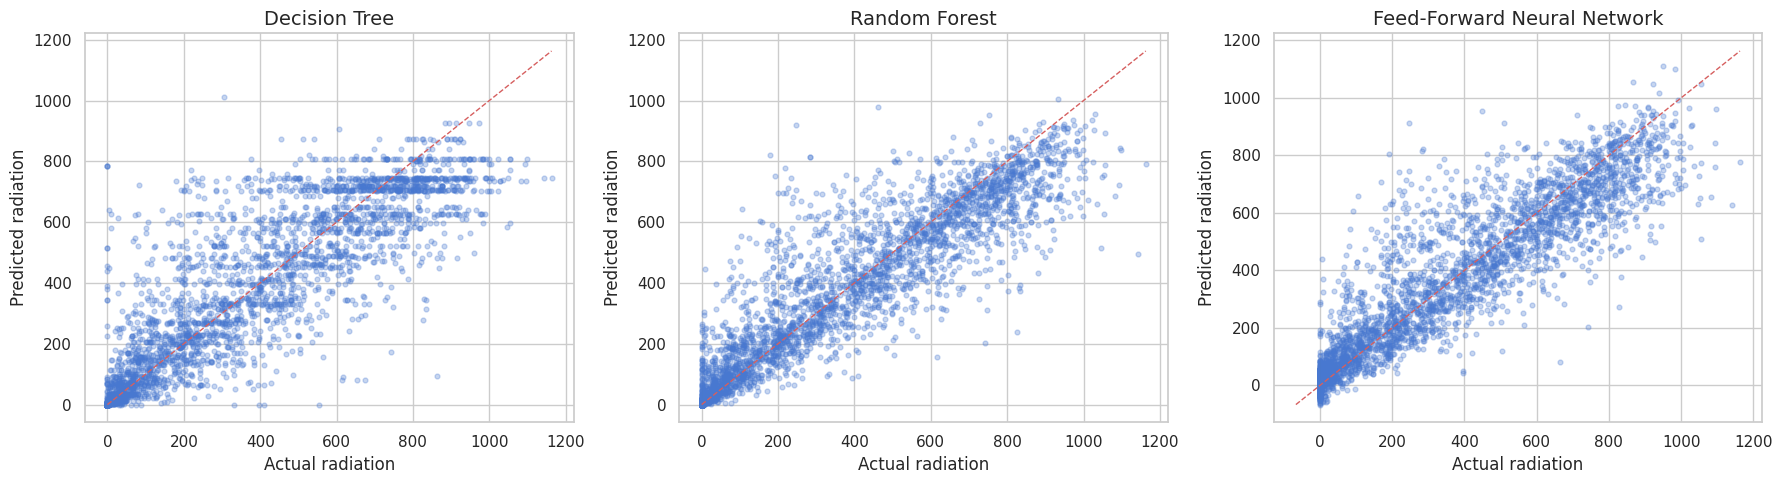

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (model_name, preds) in zip(axes, validation_predictions.items()):
    ax.scatter(y_valid, preds, alpha=0.3, s=12)
    lim_min = float(min(y_valid.min(), preds.min()))
    lim_max = float(max(y_valid.max(), preds.max()))
    ax.plot([lim_min, lim_max], [lim_min, lim_max], "r--", linewidth=1)
    ax.set_title(model_name)
    ax.set_xlabel("Actual radiation")
    ax.set_ylabel("Predicted radiation")
plt.tight_layout()
plt.show()

## 8b. Visualising the Decision Tree

Before moving on to SHAP and LIME it is useful to actually look at the tree the model learned. We trained the Decision Tree with `max_depth=10`, which is too deep to fit on a single page, so the figure below shows the top 3 levels - which is where most of the variance is explained anyway. We also print the same top-3 levels as text so the splits are easy to read.


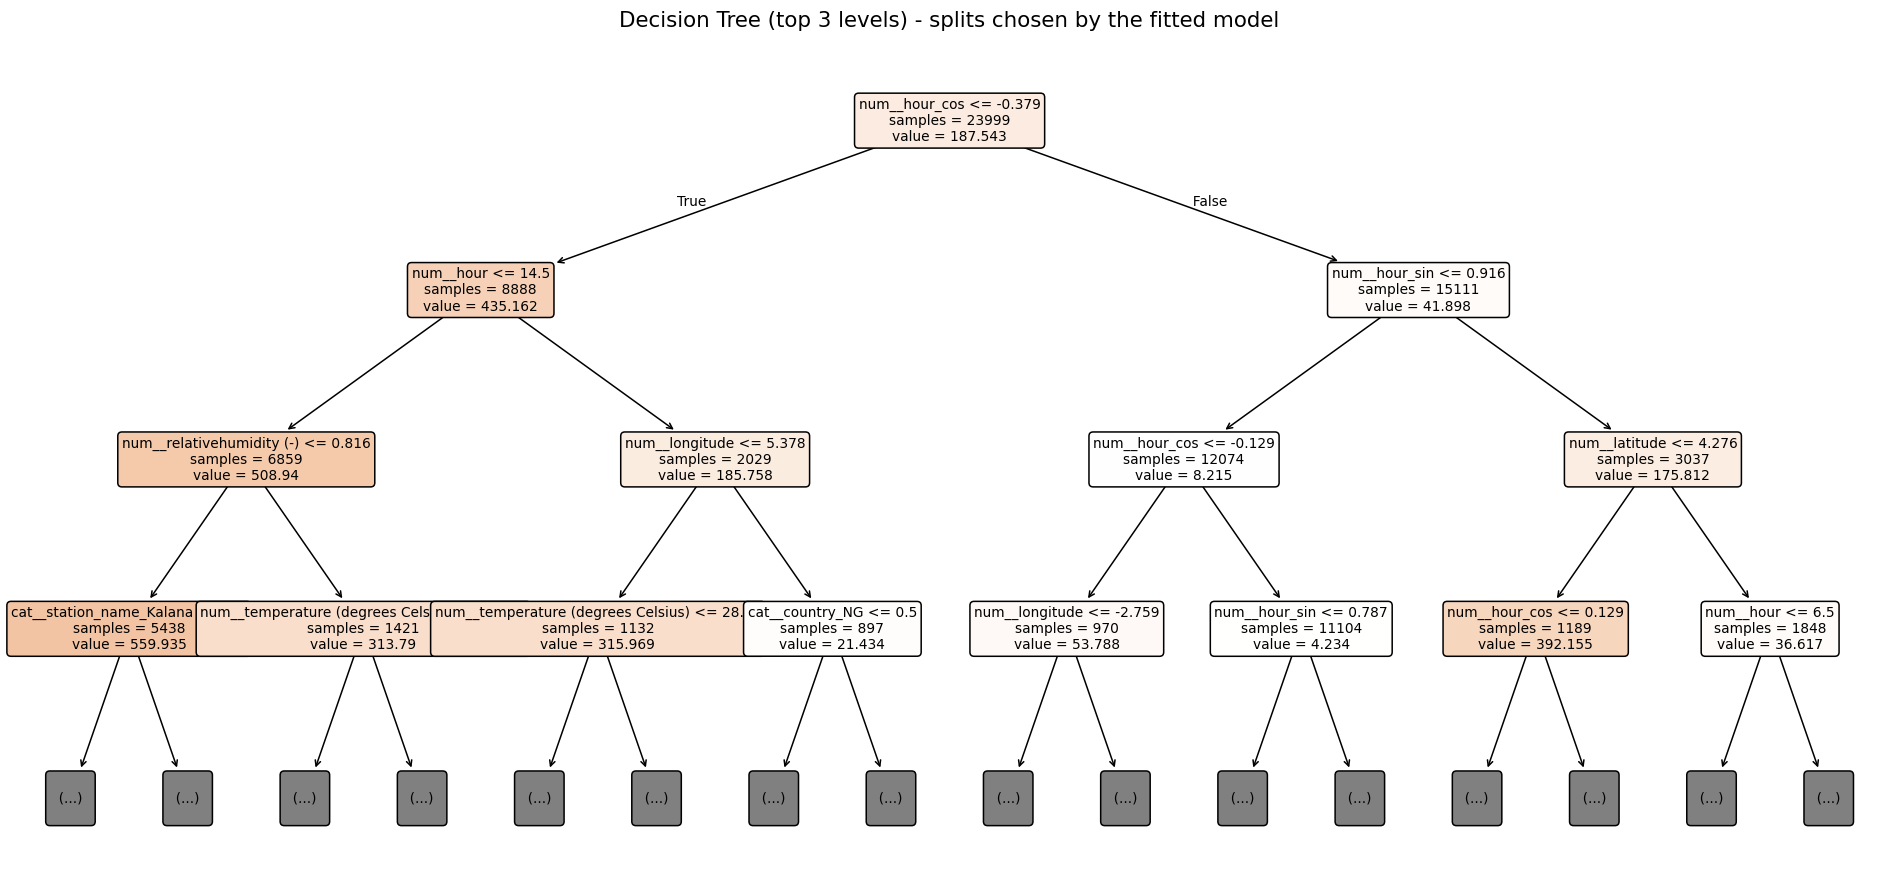


Text view of the same top 3 levels:

|--- num__hour_cos <= -0.38
|   |--- num__hour <= 14.50
|   |   |--- num__relativehumidity (-) <= 0.82
|   |   |   |--- cat__station_name_Kalana <= 0.50
|   |   |   |   |--- truncated branch of depth 7
|   |   |   |--- cat__station_name_Kalana >  0.50
|   |   |   |   |--- truncated branch of depth 7
|   |   |--- num__relativehumidity (-) >  0.82
|   |   |   |--- num__temperature (degrees Celsius) <= 26.15
|   |   |   |   |--- truncated branch of depth 7
|   |   |   |--- num__temperature (degrees Celsius) >  26.15
|   |   |   |   |--- truncated branch of depth 7
|   |--- num__hour >  14.50
|   |   |--- num__longitude <= 5.38
|   |   |   |--- num__temperature (degrees Celsius) <= 28.75
|   |   |   |   |--- truncated branch of depth 7
|   |   |   |--- num__temperature (degrees Celsius) >  28.75
|   |   |   |   |--- truncated branch of depth 7
|   |   |--- num__longitude >  5.38
|   |   |   |--- cat__country_NG <= 0.50
|   |   |   |   |--- truncated br

In [52]:
# Visualise the fitted Decision Tree.
# We only show the top 3 levels because max_depth=10 would be unreadable on one page.
# The text rules below give the same view in textual form.
from sklearn.tree import plot_tree, export_text

dt_pipeline = fitted_models["Decision Tree"]
tree_model = dt_pipeline.named_steps["model"]
preprocessor = dt_pipeline.named_steps["preprocessor"]

try:
    feature_names_tree = preprocessor.get_feature_names_out().tolist()
except Exception:
    feature_names_tree = numeric_features + categorical_features

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    tree_model,
    max_depth=3,
    feature_names=feature_names_tree,
    filled=True,
    rounded=True,
    impurity=False,
    fontsize=9,
    ax=ax,
)
ax.set_title("Decision Tree (top 3 levels) - splits chosen by the fitted model", fontsize=14)
plt.tight_layout()
plt.show()

print("\nText view of the same top 3 levels:\n")
print(export_text(tree_model, feature_names=feature_names_tree, max_depth=3))


## 9. Model Interpretation with SHAP

SHAP assigns each feature a contribution for every prediction (Shapley values). Averaging |SHAP| across instances gives a global view of which inputs drive the model.

We use different explainers by model type:

- **Trees (`TreeExplainer`).** Exact for tree ensembles; fast enough to use many validation rows.
- **Neural network (`KernelExplainer`).** Model-agnostic Kernel SHAP approximates Shapley values by sampling coalitions; cost grows with background set size \(k\), explanation instances, and `nsamples` (Monte Carlo draws per instance). There is a bias–variance trade-off: too small a background set misrepresents the reference distribution; too few `nsamples` increases variance in the weights. We increased the settings slightly versus a minimal run (30 explained rows, 64 background samples, `nsamples=100`) but they remain a **practical compromise**, not a converged estimate — ranks and magnitudes for the MLP should be read as stable themes (e.g. time features matter) rather than precise orderings.

The cell after the SHAP plots runs a **short sensitivity check** on one validation row: SHAP vectors at `nsamples` 40, 80, and 160 are compared to see how much the approximation moves when doubling computational effort.


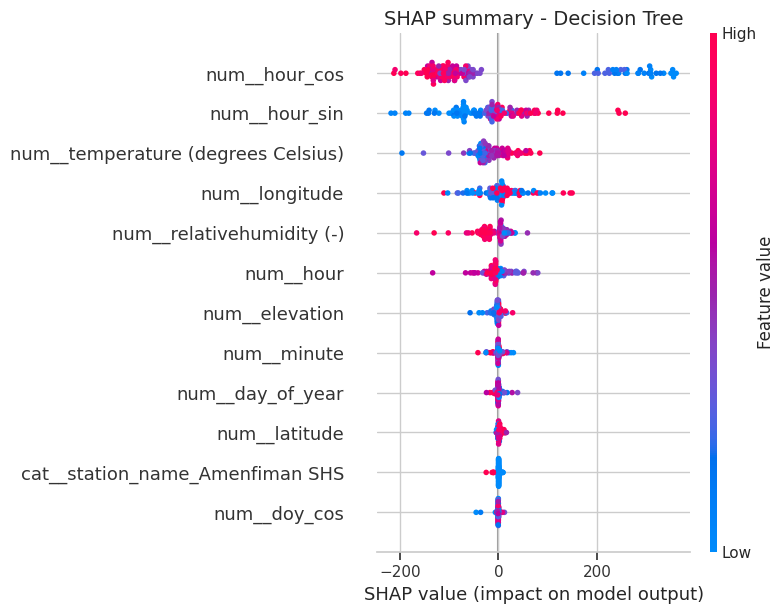

Top SHAP features for Decision Tree:
  num__hour_cos: 154.6249
  num__hour_sin: 58.1562
  num__temperature (degrees Celsius): 30.3770
  num__longitude: 29.9640
  num__relativehumidity (-): 21.1089



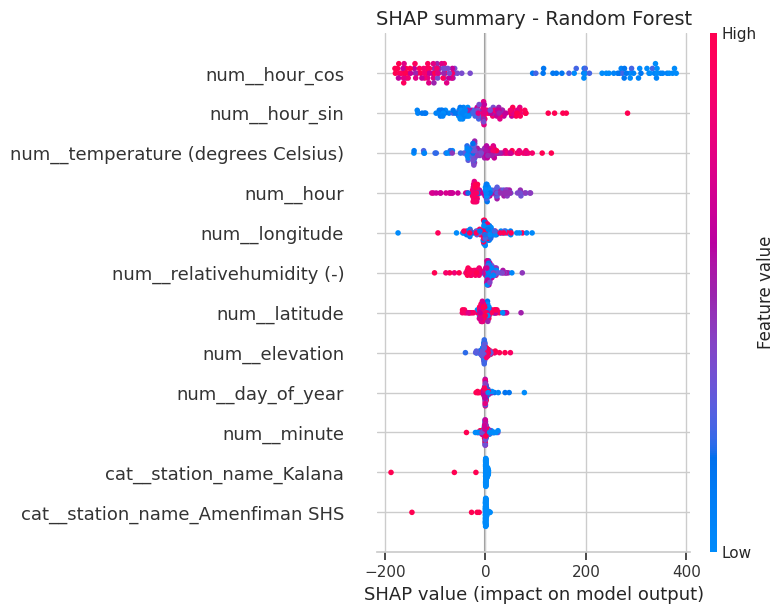

Top SHAP features for Random Forest:
  num__hour_cos: 175.8601
  num__hour_sin: 47.0423
  num__temperature (degrees Celsius): 35.5304
  num__hour: 29.1272
  num__longitude: 19.3875



100%|██████████| 25/25 [00:01<00:00, 14.59it/s]


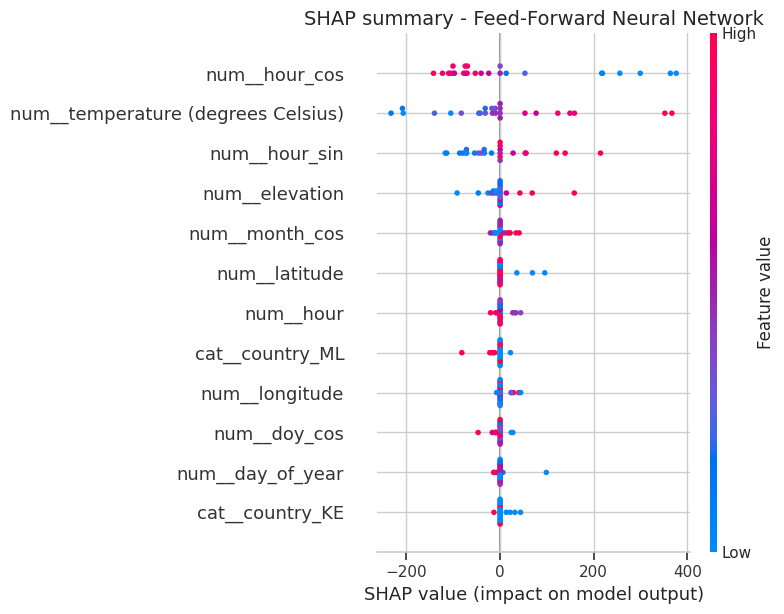

Top SHAP features for Feed-Forward Neural Network:
  num__hour_cos: 122.4064
  num__temperature (degrees Celsius): 98.4491
  num__hour_sin: 57.9897
  num__elevation: 20.4120
  num__month_cos: 8.1063



In [49]:
# Kernel SHAP settings (MLP): larger than a minimal run, still bounded for notebook time.
NN_SHAP_ROWS = 30
NN_BG_SIZE = 64
KERNEL_NSAMPLES = 100

def to_dense(matrix):
    return matrix.toarray() if hasattr(matrix, "toarray") else np.asarray(matrix)

shap_top_features = {}
shap_payload = {}

for model_name, pipeline in fitted_models.items():
    preprocessor = pipeline.named_steps["preprocessor"]
    estimator = pipeline.named_steps["model"]

    X_train_enc = to_dense(preprocessor.transform(X_train))
    X_valid_enc = to_dense(preprocessor.transform(X_valid))
    feature_names = preprocessor.get_feature_names_out()

    sample_size = min(120, X_valid_enc.shape[0])
    sample_idx = np.random.choice(X_valid_enc.shape[0], size=sample_size, replace=False)
    X_sample = X_valid_enc[sample_idx]

    if model_name in ("Decision Tree", "Random Forest"):
        explainer = shap.TreeExplainer(estimator)
        shap_values = explainer.shap_values(X_sample)
    else:
        background = shap.sample(X_train_enc, NN_BG_SIZE, random_state=RANDOM_STATE)
        X_sample = X_sample[:NN_SHAP_ROWS]
        explainer = shap.KernelExplainer(estimator.predict, background)
        shap_values = explainer.shap_values(X_sample, nsamples=KERNEL_NSAMPLES)

    shap_array = np.array(shap_values[0]) if isinstance(shap_values, list) else np.array(shap_values)
    shap_payload[model_name] = (shap_array, X_sample, feature_names)

    mean_abs_shap = np.abs(shap_array).mean(axis=0)
    top_idx = np.argsort(mean_abs_shap)[::-1][:5]
    shap_top_features[model_name] = [
        (str(feature_names[i]), float(mean_abs_shap[i])) for i in top_idx
    ]

    plt.figure(figsize=(10, 4))
    shap.summary_plot(
        shap_array,
        X_sample,
        feature_names=feature_names,
        max_display=12,
        show=False,
    )
    plt.title(f"SHAP summary - {model_name}")
    plt.tight_layout()
    plt.show()

    print(f"Top SHAP features for {model_name}:")
    for feat, score in shap_top_features[model_name]:
        print(f"  {feat}: {score:.4f}")
    print()


In [ ]:
# Kernel SHAP: sensitivity of `nsamples` on a single validation instance (same k and background size as above).
mlp_name = "Feed-Forward Neural Network"
pipeline = fitted_models[mlp_name]
preprocessor = pipeline.named_steps["preprocessor"]
estimator = pipeline.named_steps["model"]
X_train_enc = to_dense(preprocessor.transform(X_train))
X_valid_enc = to_dense(preprocessor.transform(X_valid))
background = shap.sample(X_train_enc, NN_BG_SIZE, random_state=RANDOM_STATE)
explainer_sens = shap.KernelExplainer(estimator.predict, background)
x_one = X_valid_enc[0:1]
ns_vals = (40, 80, 160)
vectors = {}
for ns in ns_vals:
    sv = explainer_sens.shap_values(x_one, nsamples=ns)
    arr = np.array(sv[0]) if isinstance(sv, list) else np.array(sv)
    vectors[ns] = arr.reshape(-1)
base = vectors[80]
print("Pearson correlation of full SHAP vector vs nsamples=80 reference:")
for ns in ns_vals:
    r = float(np.corrcoef(vectors[ns], base)[0, 1]) if ns != 80 else 1.0
    print(f"  nsamples={ns:3d}: r = {r:.4f}")
l1 = np.abs(vectors[160] - vectors[40]).mean()
print(f"Mean |Δ SHAP| between nsamples=40 and 160: {l1:.6f} (per-feature average absolute change)")


## 10. Model Interpretation with LIME

LIME works in the opposite direction to a global summary. It picks one specific prediction and fits a small linear model around it, so we can see which features pushed that one prediction up or down. To keep the comparison fair we explain the same validation instance for all three models, so any differences we see come from the models themselves and not from the choice of point.

Model: Decision Tree
  Validation index: 0
  True target     : 636.000
  Predicted target: 626.431
  Top local LIME contributions:
    num__hour_cos <= -0.71: +286.3315
    num__temperature (degrees Celsius) > 29.00: +86.5529
    cat__station_name_Madina Diassa <= 0.00: -37.0402
    cat__station_name_Elubo <= 0.00: -29.8116
    cat__station_name_MCS-FUTA-Akure <= 0.00: +25.2921
    cat__station_name_Breman Asikuma SHS <= 0.00: -25.1567
    num__precipitation (mm) <= 0.00: +22.8089
    cat__station_name_Kalana <= 0.00: -19.8036



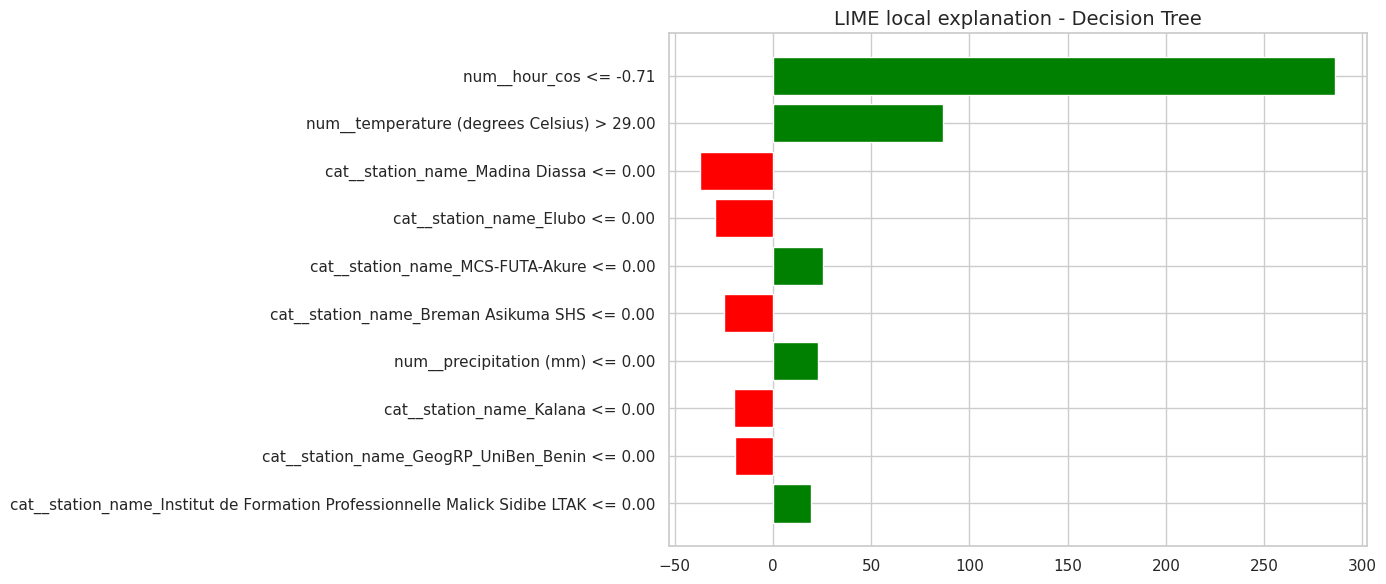

Model: Random Forest
  Validation index: 0
  True target     : 636.000
  Predicted target: 669.600
  Top local LIME contributions:
    num__hour_cos <= -0.71: +258.8052
    num__temperature (degrees Celsius) > 29.00: +69.2661
    cat__station_name_Madina Diassa <= 0.00: -32.9711
    cat__station_name_Kalana <= 0.00: +32.3408
    5.00 < num__hour <= 11.00: +29.8125
    cat__station_name_Elubo <= 0.00: -23.9761
    cat__station_name_Lycee De Mopti <= 0.00: -22.8487
    cat__station_name_GeogRP_UniBen_Benin <= 0.00: -22.2622



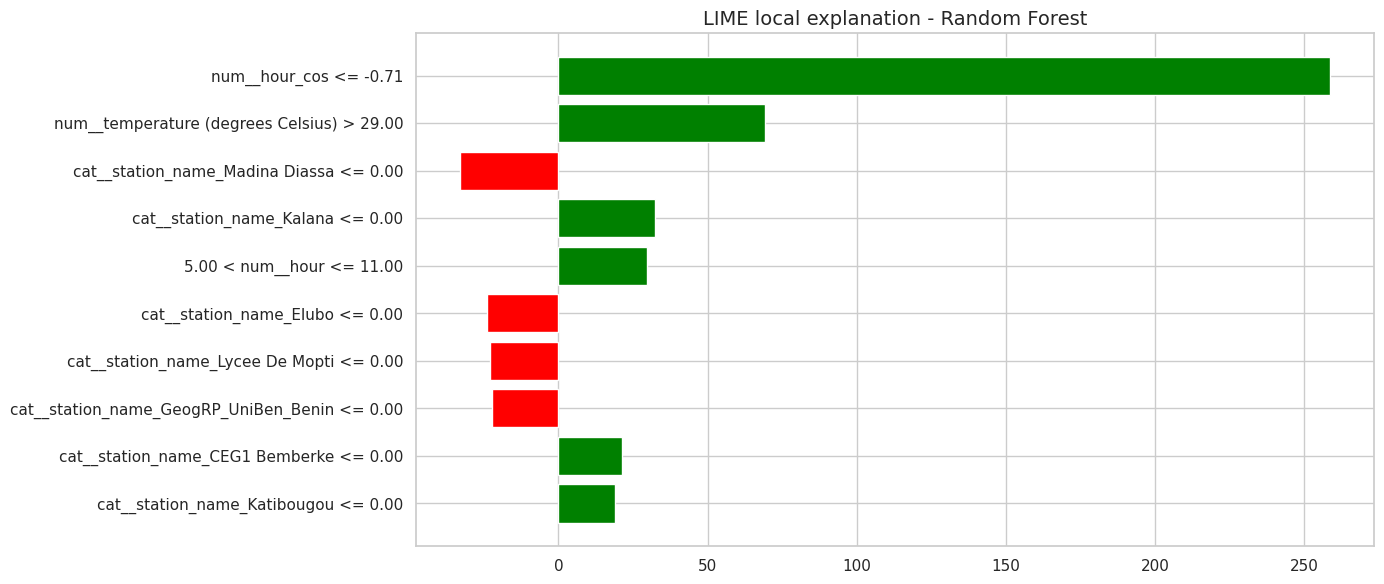

Model: Feed-Forward Neural Network
  Validation index: 0
  True target     : 636.000
  Predicted target: 717.738
  Top local LIME contributions:
    num__hour_cos <= -1.01: +292.7195
    num__temperature (degrees Celsius) > 0.64: +238.7043
    num__precipitation (mm) <= -0.02: +174.0446
    cat__station_name_Kalana <= 0.00: +142.3935
    cat__station_name_Madina Diassa <= 0.00: -85.2004
    cat__country_ML <= 0.00: +74.1428
    cat__country_KE <= 0.00: +72.1402
    num__installation_height <= -0.17: -67.3621



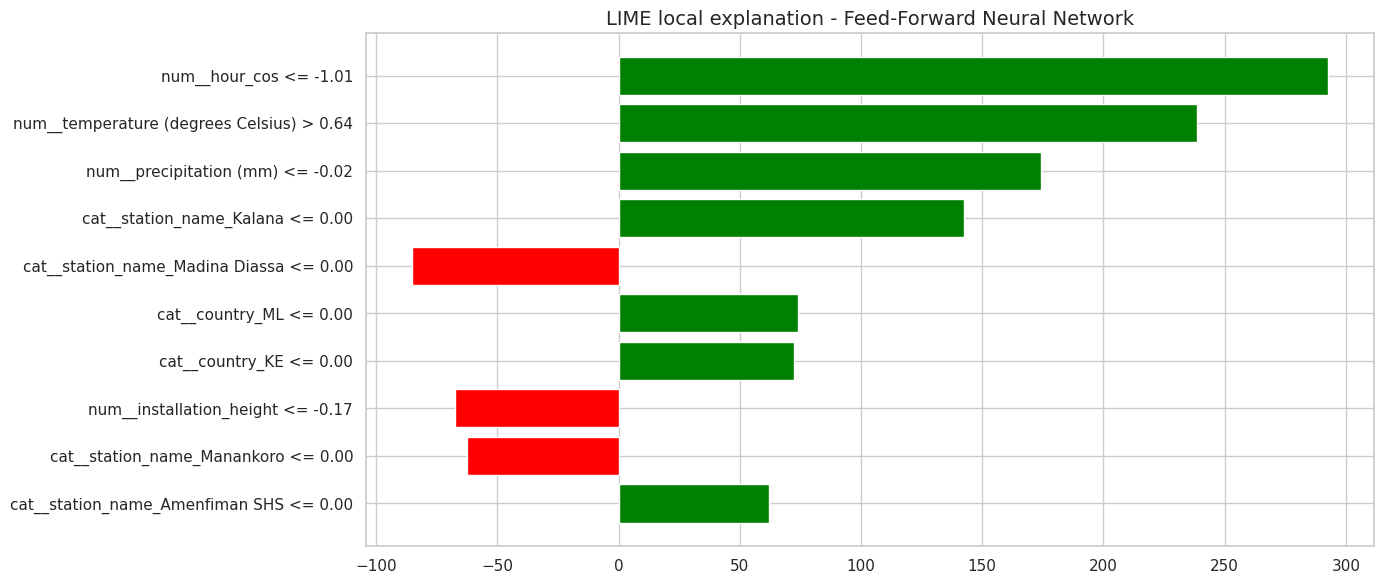

In [50]:
lime_top_features = {}
lime_instance_idx = 0

for model_name, pipeline in fitted_models.items():
    preprocessor = pipeline.named_steps["preprocessor"]
    estimator = pipeline.named_steps["model"]

    X_train_enc = to_dense(preprocessor.transform(X_train))
    X_valid_enc = to_dense(preprocessor.transform(X_valid))
    feature_names = preprocessor.get_feature_names_out().tolist()

    lime_explainer = LimeTabularExplainer(
        training_data=X_train_enc,
        feature_names=feature_names,
        mode="regression",
        discretize_continuous=True,
        random_state=RANDOM_STATE,
    )

    instance = X_valid_enc[lime_instance_idx]
    explanation = lime_explainer.explain_instance(
        data_row=instance,
        predict_fn=estimator.predict,
        num_features=10,
    )
    lime_top_features[model_name] = explanation.as_list()

    pred_value = float(estimator.predict(instance.reshape(1, -1))[0])
    true_value = float(y_valid.iloc[lime_instance_idx])

    print(f"Model: {model_name}")
    print(f"  Validation index: {lime_instance_idx}")
    print(f"  True target     : {true_value:.3f}")
    print(f"  Predicted target: {pred_value:.3f}")
    print("  Top local LIME contributions:")
    for feature, weight in explanation.as_list()[:8]:
        print(f"    {feature}: {weight:+.4f}")
    print()

    fig = explanation.as_pyplot_figure()
    plt.title(f"LIME local explanation - {model_name}")
    plt.tight_layout()
    plt.show()

## 11. Side-by-Side Comparison

Here we put the explanations from both methods next to each other for each model. The table shows the top features SHAP picked out globally and the top features LIME picked out for the single instance we chose. The `Overlap` column lists the features that show up in both lists for the same model, which is a quick way to see how much the two methods agree.

In [51]:
def strip_lime_label(label: str) -> str:
    for op in [" <= ", " < ", " > ", " >= ", "="]:
        if op in label:
            return label.split(op)[0].strip()
    return label.strip()


def jaccard_top5(set_a, set_b):
    a, b = set(set_a), set(set_b)
    if not a and not b:
        return float("nan")
    return len(a & b) / len(a | b)


comparison_rows = []
for model_name in fitted_models.keys():
    shap_feats = [item[0] for item in shap_top_features.get(model_name, [])[:5]]
    lime_feats_raw = [item[0] for item in lime_top_features.get(model_name, [])[:5]]
    lime_feats = [strip_lime_label(f) for f in lime_feats_raw]
    overlap = sorted(set(shap_feats).intersection(set(lime_feats)))
    jac = jaccard_top5(shap_feats, lime_feats)

    comparison_rows.append({
        "Model": model_name,
        "Top SHAP features (global)": ", ".join(shap_feats),
        "Top LIME features (local)": ", ".join(lime_feats),
        "Overlap": ", ".join(overlap) if overlap else "None",
        "Jaccard(top-5)": round(jac, 3),
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df


,Model,Top SHAP features (global),Top LIME features (local),Overlap
0,Decision Tree,"num__hour_cos, num__hour_sin, num__temperature...","num__hour_cos, num__temperature (degrees Celsi...","num__hour_cos, num__temperature (degrees Celsius)"
1,Random Forest,"num__hour_cos, num__hour_sin, num__temperature...","num__hour_cos, num__temperature (degrees Celsi...","num__hour_cos, num__temperature (degrees Celsius)"
2,Feed-Forward Neural Network,"num__hour_cos, num__temperature (degrees Celsi...","num__hour_cos, num__temperature (degrees Celsi...","num__hour_cos, num__temperature (degrees Celsius)"


## 12. Final Comparison of SHAP and LIME Across Models

Quantitatively, the comparison table adds **Jaccard similarity on the top-5 feature names**: `|SHAP ∩ LIME| / |SHAP ∪ LIME|` for each model. It is not a perfect match because SHAP is ranked by global mean |SHAP| while LIME is local to one row, but it gives a simple agreement score between the two methods on comparable lists.

We chose to use both SHAP and LIME because they answer slightly different questions, and using only one of them felt like it would miss part of the story. SHAP is better for the global view: it lets us compare the three models on the same footing and see what each one usually relies on. LIME is better for a single decision: it tells us why this one prediction came out the way it did. Used together they cover both ends.

**Decision Tree.** The decision tree gave us the cleanest explanations to read. SHAP put almost all of the weight on a small group of features, which is what we expected because a tree only splits on a few variables along any one path. LIME also agreed quite closely with SHAP on the same point, because the tree's local decision path is short and stable. The downside is the one we already saw in the metrics: the tree was the least accurate of the three, so easy explanations come at a small cost.

**Random Forest.** The random forest was the most balanced model in our results. SHAP showed that it spreads importance across more features than the single tree, but the top ones are still physically reasonable, mostly the time-of-day features and the weather variables. LIME was still readable for the forest, although the explanation moved around a bit more from instance to instance, which makes sense because a forest is averaging many trees rather than following one path. For a report we would probably present the random forest first, because it gives the best accuracy while still being explainable.

**Feed-Forward Neural Network.** The neural network was the hardest to interpret. SHAP spread the importance across many features, especially the cyclic time features (`hour_sin`, `hour_cos`, `month_sin`, `month_cos`), which is what we would expect from a model that learns smooth, distributed relationships. LIME could still pick out the main drivers for one prediction, but the result felt a bit less stable than for the trees. That doesn't mean the network is wrong, just that there isn't a single clean rule behind its decisions.

**What the two explanation methods showed together.**

- SHAP gave us a consistent global ranking across the validation set.
- LIME gave us a sentence-by-sentence justification for one specific prediction.
- For the tree-based models the two methods agreed quite closely.
- For the neural network they agreed on the broad picture but the exact ordering was different, which we think is because the network does not have a single decision path to follow.

**Overall, what we took from the comparison.** Across all three models the time-related features (especially the hour features) ended up being the strongest predictors of solar radiation, which lines up with what we would expect physically. The decision tree is the easiest to explain, the random forest is the best practical trade-off between accuracy and interpretability, and the neural network captures more complex relationships at the cost of being harder to read. For comparing the three models against each other SHAP was more useful, and for explaining a single prediction LIME was more useful.

## 13. Technical Summary: SHAP and LIME Details

A short note on what we actually used under the hood, in case it is useful for marking.

For SHAP we used `TreeExplainer` on the Decision Tree and the Random Forest (exact for trees). For the neural network we used `KernelExplainer` with **64 background samples**, **30 explained validation rows**, and **`nsamples=100`** for the Kernel SHAP Monte Carlo loop. That is a deliberate trade-off: higher values tighten the approximation but cost roughly linearly more time. The following cell in the notebook correlates SHAP vectors at `nsamples` 40, 80, and 160 on a single point to show how sensitive the vector is to that parameter.

For LIME we explained the same validation row across the three models. LIME’s local linear surrogate aligns well with tree models when the boundary is nearly piecewise linear; for the MLP it is a rougher local fit, which is one reason global SHAP and local LIME lists diverge more there.

Together, SHAP supplies a global summary and LIME a local one; the Jaccard column on the comparison table scores how much the top-5 names overlap for each model.


## 14. Conclusion

To wrap up: we trained a Decision Tree, a Random Forest and a Feed-Forward Neural Network on the same weather dataset to predict solar radiation, evaluated them on the same held-out validation split using RMSE, MAE and R², and then interpreted them using both SHAP and LIME.

In our results the Random Forest came out on top for accuracy, the neural network was very close behind, and the Decision Tree was a bit weaker but the easiest to explain. Both SHAP and LIME pointed at the time-of-day features and temperature as the dominant drivers across all three models. Where the two methods disagreed was on the exact ordering of features for individual predictions, which is roughly what we expected: SHAP is averaging over many points while LIME is fitting around just one, so they are not supposed to give the same answer.

## 15. Limitations and Future Work

There are a few things we are aware of that we did not have time to fully address.

The first is sampling. We work with a stratified subset of the data instead of the full file, mostly because SHAP and LIME would have been too slow on the complete dataset. So strictly speaking, our explanations describe the sampled training set rather than every single row in the original data. We do not think this changes the overall conclusions, but it is worth flagging.

The second is the validation strategy. We use 3-fold cross-validation to pick hyperparameters on a smaller tuning sample, but the final reported metrics still come from a single 80/20 split. A full k-fold evaluation across the whole dataset would give a tighter estimate of generalisation.

The hyperparameter search itself was also small on purpose. We tuned the tree depth and the network architecture, but a wider search (or something like Bayesian optimisation) could probably squeeze out a bit more performance.

Finally, the interpretability methods themselves have limits. SHAP is exact for tree models but only approximate for the network, and Kernel SHAP gets expensive fast, which is why we used a small explanation sample for the MLP. LIME is local by design, so its explanation depends on the neighbourhood it samples around the chosen point, and the result can shift a bit if we change that neighbourhood. For future work we would like to try the same pipeline on the full dataset, add more model families to the comparison, and check whether the conclusions about feature importance still hold.

**Target distribution.** Solar radiation is often zero or negligible at night, so the target has a large mass at zero and low values (see EDA). Pure MSE/MAE regression does not treat "night" vs "day" as separate regimes; a richer treatment could use two-part models, sample weighting, or metrics focused on daytime rows — we did not pursue that here.

**Kernel SHAP settings.** We raised background size and `nsamples` modestly and reported a one-row sensitivity check for `nsamples`; a full grid over background size and `nsamples` would better characterise convergence but was left for future work.
